# **Sentiment Analysis** - IMDB Dataset

Contains next sections:
- **Section 1:** Imports
- **Section 2:** Loading and preparing data
- **Section 3:** Split data
- **Section 4:** TF-IDF vectorization
- **Section 5:** Algorithm 1
- **Section 6:** Algorithm 2
- **Section 7:** LDA analysis for classification
- **Section 8:** Final testing on an independent test set
- **Section 9:** Data visualization
- **Section 10:** Final results and saving the model
- **Section 11:** Additional analysis

## **Section 1:** Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           classification_report, confusion_matrix)
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from itertools import cycle

import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import utils 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\iam0v\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\iam0v\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\iam0v\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## **Section 2:** Loading and preparing data

In [2]:
print("="*50)
print("KLASIFIKACIJA - 20 Newsgroups")
print("="*50)

# Učitavanje podataka
folder_path = r"C:\Users\iam0v\Downloads\datasets\20_newsgroups"
X, y, target_names = utils.load_data_from_folder(folder_path)

print(f"Ukupno tekstova: {len(X)}")
print(f"Ukupno labela: {len(y)}")
print(f"Broj klasa: {len(target_names)}")
print(f"Klase: {target_names[:5]}...") 

KLASIFIKACIJA - 20 Newsgroups
Ukupno tekstova: 19997
Ukupno labela: 19997
Broj klasa: 20
Klase: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware']...


## **Section 3:** Split data

In [3]:
# VAŽNO: Izdvajanje finalnog test skupa (15%)
X_temp_class, X_final_test_class, y_temp_class, y_final_test_class = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Podela na train i validation
X_train_class, X_val_class, y_train_class, y_val_class = train_test_split(
    X_temp_class, y_temp_class, test_size=0.2, random_state=42, stratify=y_temp_class
)

print(f"Train set: {len(X_train_class)} samples")
print(f"Validation set: {len(X_val_class)} samples")
print(f"Final test set: {len(X_final_test_class)} samples")

# Distribucija klasa
print(f"\nDistribucija klasa u training setu:")
unique, counts = np.unique(y_train_class, return_counts=True)
for i, count in zip(unique[:5], counts[:5]):  # Prikaži prvih 5
    print(f"Klasa {i} ({target_names[i]}): {count} uzoraka")

Train set: 13597 samples
Validation set: 3400 samples
Final test set: 3000 samples

Distribucija klasa u training setu:
Klasa 0 (alt.atheism): 680 uzoraka
Klasa 1 (comp.graphics): 680 uzoraka
Klasa 2 (comp.os.ms-windows.misc): 680 uzoraka
Klasa 3 (comp.sys.ibm.pc.hardware): 680 uzoraka
Klasa 4 (comp.sys.mac.hardware): 680 uzoraka


## **Section 4:** TF-IDF vectorization

In [4]:
# TF-IDF vektorizacija
tfidf_class = TfidfVectorizer(stop_words='english', max_df=0.5, max_features=10000)
X_train_tfidf_class = tfidf_class.fit_transform(X_train_class)
X_val_tfidf_class = tfidf_class.transform(X_val_class)
X_final_tfidf_class = tfidf_class.transform(X_final_test_class)

print(f"TF-IDF feature matrix shape: {X_train_tfidf_class.shape}")
print(f"Broj features: {X_train_tfidf_class.shape[1]}")
print(f"Sparsity: {(1 - X_train_tfidf_class.nnz / (X_train_tfidf_class.shape[0] * X_train_tfidf_class.shape[1])) * 100:.2f}%")

TF-IDF feature matrix shape: (13597, 10000)
Broj features: 10000
Sparsity: 99.06%


## **Section 5:** Algorithm 1

In [5]:
print("\n--- Algoritam 3: Naive Bayes ---")

# Grid Search za Naive Bayes
print("Grid Search za Naive Bayes...")
param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
}

nb_classifier = MultinomialNB()
grid_search_nb = GridSearchCV(nb_classifier, param_grid_nb, 
                             cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search_nb.fit(X_train_tfidf_class, y_train_class)

print(f"Najbolji NB parametri: {grid_search_nb.best_params_}")
print(f"Najbolji CV score: {grid_search_nb.best_score_:.4f}")

best_nb = grid_search_nb.best_estimator_


--- Algoritam 3: Naive Bayes ---
Grid Search za Naive Bayes...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Najbolji NB parametri: {'alpha': 2.0}
Najbolji CV score: 0.8858


In [6]:
# Evaluacija Naive Bayes na validation setu
nb_val_pred = best_nb.predict(X_val_tfidf_class)
nb_val_acc = accuracy_score(y_val_class, nb_val_pred)
nb_val_f1 = f1_score(y_val_class, nb_val_pred, average='macro')

print(f"\nNaive Bayes - Validation rezultati:")
print(f"Accuracy: {nb_val_acc:.4f}")
print(f"F1-score (macro): {nb_val_f1:.4f}")

# Detaljniji izveštaj za prvih nekoliko klasa
print(f"\nDetaljni izveštaj (prve 3 klase):")
print(classification_report(y_val_class, nb_val_pred, target_names=target_names, 
                          labels=range(3), zero_division=0))


Naive Bayes - Validation rezultati:
Accuracy: 0.8844
F1-score (macro): 0.8824

Detaljni izveštaj (prve 3 klase):
                          precision    recall  f1-score   support

             alt.atheism       0.77      0.83      0.80       170
           comp.graphics       0.88      0.86      0.87       170
 comp.os.ms-windows.misc       0.84      0.93      0.89       170

               micro avg       0.83      0.87      0.85       510
               macro avg       0.83      0.87      0.85       510
            weighted avg       0.83      0.87      0.85       510



C:\Users\iam0v\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2964: UserWarning: labels size, 3, does not match size of target_names, 20
  warnings.warn(


Classification Report za Naive Bayes:


,precision,recall,f1-score,support
alt.atheism,0.774725,0.829412,0.801136,170.000000
comp.graphics,0.875000,0.864706,0.869822,170.000000
comp.os.ms-windows.misc,0.844920,0.929412,0.885154,170.000000
comp.sys.ibm.pc.hardware,0.802198,0.858824,0.829545,170.000000
comp.sys.mac.hardware,0.897590,0.876471,0.886905,170.000000
comp.windows.x,0.918239,0.858824,0.887538,170.000000
misc.forsale,0.923529,0.923529,0.923529,170.000000
rec.autos,0.946429,0.935294,0.940828,170.000000
rec.motorcycles,0.931429,0.958824,0.944928,170.000000
rec.sport.baseball,0.969880,0.947059,0.958333,170.000000


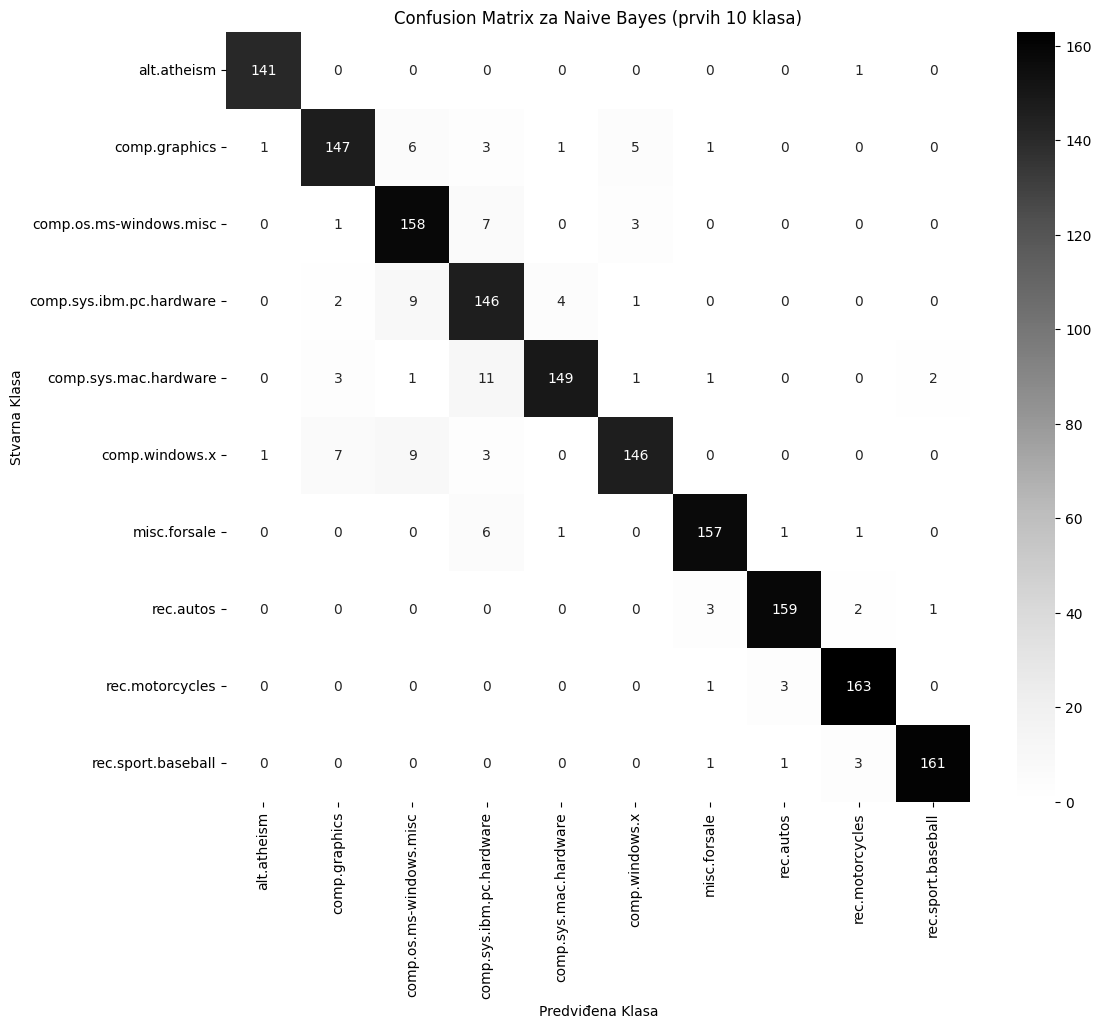

Accuracy: 0.8844
Macro Precision: 0.8838, Macro Recall: 0.8844, Macro F1: 0.8824


In [27]:
# Classification report kao tabela  
print("Classification Report za Naive Bayes:")
report_nb = classification_report(y_val_class, nb_val_pred, target_names=target_names, output_dict=True)
df_report_nb = pd.DataFrame(report_nb).transpose()
display(df_report_nb)

# Confusion matrix
cm_nb = confusion_matrix(y_val_class, nb_val_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_nb[:10, :10], annot=True, fmt='d', cmap='Grays', 
            xticklabels=target_names[:10], yticklabels=target_names[:10])
plt.title('Confusion Matrix za Naive Bayes (prvih 10 klasa)')
plt.xlabel('Predviđena Klasa')
plt.ylabel('Stvarna Klasa')
plt.savefig('confusion_matrix_nb_val.png')
plt.show()

# Macro metrike (koristite postojeće varijable)
prec_nb = precision_score(y_val_class, nb_val_pred, average='macro')
rec_nb = recall_score(y_val_class, nb_val_pred, average='macro')
print(f"Accuracy: {nb_val_acc:.4f}")
print(f"Macro Precision: {prec_nb:.4f}, Macro Recall: {rec_nb:.4f}, Macro F1: {nb_val_f1:.4f}")

## **Section 6:** Algorithm 2

In [8]:
print("\n--- Algoritam 4: Random Forest ---")

# Grid Search za Random Forest
print("Grid Search za Random Forest...")
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_classifier = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(rf_classifier, param_grid_rf, 
                             cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train_tfidf_class, y_train_class)

print(f"Najbolji RF parametri: {grid_search_rf.best_params_}")
print(f"Najbolji CV score: {grid_search_rf.best_score_:.4f}")

best_rf = grid_search_rf.best_estimator_


--- Algoritam 4: Random Forest ---
Grid Search za Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Najbolji RF parametri: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Najbolji CV score: 0.9512


In [9]:
# Evaluacija Random Forest na validation setu
rf_val_pred = best_rf.predict(X_val_tfidf_class)
rf_val_acc = accuracy_score(y_val_class, rf_val_pred)
rf_val_f1 = f1_score(y_val_class, rf_val_pred, average='macro')

print(f"\nRandom Forest - Validation rezultati:")
print(f"Accuracy: {rf_val_acc:.4f}")
print(f"F1-score (macro): {rf_val_f1:.4f}")

# Feature importance
feature_importance = best_rf.feature_importances_
feature_names = tfidf_class.get_feature_names_out()
top_features_idx = np.argsort(feature_importance)[-10:]  # Top 10 features

print(f"\nTop 10 najvažnijih features:")
for i, idx in enumerate(reversed(top_features_idx)):
    print(f"{i+1}. {feature_names[idx]}: {feature_importance[idx]:.4f}")


Random Forest - Validation rezultati:
Accuracy: 0.9456
F1-score (macro): 0.9455

Top 10 najvažnijih features:
1. misc: 0.0221
2. sci: 0.0212
3. autos: 0.0212
4. motorcycle: 0.0207
5. windows: 0.0192
6. electronics: 0.0190
7. graphics: 0.0184
8. sys: 0.0179
9. baseball: 0.0168
10. forsale: 0.0163


Classification Report za Random Forest:


,precision,recall,f1-score,support
alt.atheism,0.796407,0.782353,0.789318,170.000000
comp.graphics,0.982249,0.976471,0.979351,170.000000
comp.os.ms-windows.misc,0.988166,0.982353,0.985251,170.000000
comp.sys.ibm.pc.hardware,0.965318,0.982353,0.973761,170.000000
comp.sys.mac.hardware,0.976608,0.982353,0.979472,170.000000
comp.windows.x,0.982558,0.994118,0.988304,170.000000
misc.forsale,0.965318,0.982353,0.973761,170.000000
rec.autos,0.988166,0.982353,0.985251,170.000000
rec.motorcycles,0.994083,0.988235,0.991150,170.000000
rec.sport.baseball,1.000000,0.994118,0.997050,170.000000


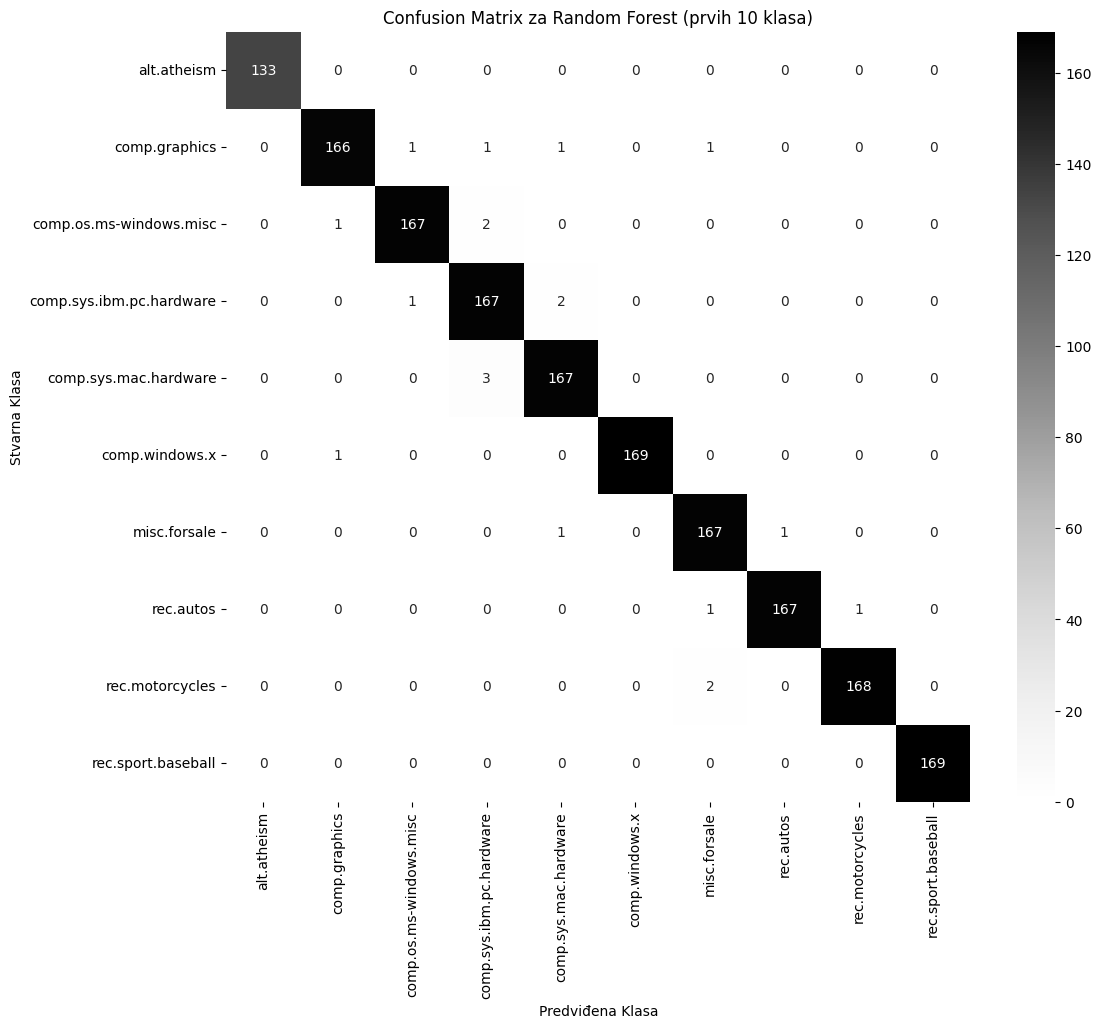

Macro Precision: 0.9457, Macro Recall: 0.9456


In [25]:
# Classification report kao tabela
print("Classification Report za Random Forest:")
report_rf = classification_report(y_val_class, rf_val_pred, target_names=target_names, output_dict=True)
df_report_rf = pd.DataFrame(report_rf).transpose()
display(df_report_rf)

# Confusion matrix
cm_rf = confusion_matrix(y_val_class, rf_val_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_rf[:10, :10], annot=True, fmt='d', cmap='Greys', 
            xticklabels=target_names[:10], yticklabels=target_names[:10])
plt.title('Confusion Matrix za Random Forest (prvih 10 klasa)')
plt.xlabel('Predviđena Klasa')
plt.ylabel('Stvarna Klasa')
plt.savefig('confusion_matrix_rf_val.png')
plt.show()

# Macro metrike
prec_rf = precision_score(y_val_class, rf_val_pred, average='macro')
rec_rf = recall_score(y_val_class, rf_val_pred, average='macro')
print(f"Macro Precision: {prec_rf:.4f}, Macro Recall: {rec_rf:.4f}")

## **Section 7:** LDA analysis for classification

In [10]:
print("\n--- Primena LDA na klasifikaciju ---")

# LDA (maksimalno n_classes - 1 komponenti)
n_components = min(19, X_train_tfidf_class.shape[1])  # 20 klasa - 1 = 19
lda = LinearDiscriminantAnalysis(n_components=n_components)
X_train_lda = lda.fit_transform(X_train_tfidf_class.toarray(), y_train_class)
X_val_lda = lda.transform(X_val_tfidf_class.toarray())

print(f"Originalna dimenzionalnost: {X_train_tfidf_class.shape[1]}")
print(f"LDA dimenzionalnost: {X_train_lda.shape[1]}")
print(f"Objašnjena varijansa prvih 5 komponenti: {lda.explained_variance_ratio_[:5]}")
print(f"Ukupna objašnjena varijansa: {lda.explained_variance_ratio_.sum():.4f}")


--- Primena LDA na klasifikaciju ---
Originalna dimenzionalnost: 10000
LDA dimenzionalnost: 19
Objašnjena varijansa prvih 5 komponenti: [0.20650364 0.1102407  0.09561729 0.08841499 0.07009478]
Ukupna objašnjena varijansa: 1.0000


In [11]:
# Grid Search za NB sa LDA
print("\nGrid Search za Naive Bayes sa LDA features...")

# Normalizacija da izbegnemo negativne vrednosti nakon LDA
X_train_lda_norm = np.abs(X_train_lda) + 1e-10
X_val_lda_norm = np.abs(X_val_lda) + 1e-10

nb_lda = MultinomialNB()
grid_search_nb_lda = GridSearchCV(nb_lda, param_grid_nb, 
                                 cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search_nb_lda.fit(X_train_lda_norm, y_train_class)

print(f"Najbolji NB-LDA parametri: {grid_search_nb_lda.best_params_}")
print(f"Najbolji CV score sa LDA: {grid_search_nb_lda.best_score_:.4f}")

# Poređenje performansi
if grid_search_nb.best_score_ > grid_search_nb_lda.best_score_:
    print("Naive Bayes radi bolje BEZ LDA redukcije")
    use_lda_nb = False
else:
    print("Naive Bayes radi bolje SA LDA redukcijom")  
    use_lda_nb = True


Grid Search za Naive Bayes sa LDA features...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Najbolji NB-LDA parametri: {'alpha': 0.01}
Najbolji CV score sa LDA: 0.9797
Naive Bayes radi bolje SA LDA redukcijom


In [12]:
# Grid Search za RF sa LDA
print("\nGrid Search za Random Forest sa LDA features...")
rf_lda = RandomForestClassifier(random_state=42)
grid_search_rf_lda = GridSearchCV(rf_lda, param_grid_rf, 
                                 cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search_rf_lda.fit(X_train_lda, y_train_class)

print(f"Najbolji RF-LDA parametri: {grid_search_rf_lda.best_params_}")
print(f"Najbolji CV score sa LDA: {grid_search_rf_lda.best_score_:.4f}")

# Poređenje performansi
if grid_search_rf.best_score_ > grid_search_rf_lda.best_score_:
    print("Random Forest radi bolje BEZ LDA redukcije")
    use_lda_rf = False
else:
    print("Random Forest radi bolje SA LDA redukcijom")
    use_lda_rf = True


Grid Search za Random Forest sa LDA features...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Najbolji RF-LDA parametri: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Najbolji CV score sa LDA: 0.9758
Random Forest radi bolje SA LDA redukcijom


## **Section 8:** Final testing on an independent test set

In [13]:
print("\n" + "="*50)
print("FINALNO TESTIRANJE NA NEZAVISNOM TEST SKUPU")
print("="*50)

print("\n--- KLASIFIKACIJA (20 Newsgroups) ---")

# Kombinovanje train i validation setova za finalno treniranje
X_full_train_class = X_train_class + X_val_class
y_full_train_class = np.concatenate([y_train_class, y_val_class])

print(f"Finalni training set: {len(X_full_train_class)} samples")

# TF-IDF na celom training skupu
X_full_tfidf_class = tfidf_class.fit_transform(X_full_train_class)
X_test_tfidf_class = tfidf_class.transform(X_final_test_class)

print(f"Finalni TF-IDF shape: {X_full_tfidf_class.shape}")


FINALNO TESTIRANJE NA NEZAVISNOM TEST SKUPU

--- KLASIFIKACIJA (20 Newsgroups) ---
Finalni training set: 16997 samples
Finalni TF-IDF shape: (16997, 10000)


In [14]:
# 3. Naive Bayes - finalno treniranje
if use_lda_nb:
    print("Koristi se Naive Bayes SA LDA")
    X_full_lda = lda.fit_transform(X_full_tfidf_class.toarray(), y_full_train_class)
    X_test_lda = lda.transform(X_test_tfidf_class.toarray())
    X_full_lda_norm = np.abs(X_full_lda) + 1e-10
    X_test_lda_norm = np.abs(X_test_lda) + 1e-10
    grid_search_nb_lda.best_estimator_.fit(X_full_lda_norm, y_full_train_class)
    nb_pred = grid_search_nb_lda.best_estimator_.predict(X_test_lda_norm)
else:
    print("Koristi se Naive Bayes BEZ LDA")
    best_nb.fit(X_full_tfidf_class, y_full_train_class)
    nb_pred = best_nb.predict(X_test_tfidf_class)

print(f"\nNaive Bayes rezultati:")
print(classification_report(y_final_test_class, nb_pred, target_names=target_names, zero_division=0))
nb_acc = accuracy_score(y_final_test_class, nb_pred)
nb_f1 = f1_score(y_final_test_class, nb_pred, average='macro')
print(f"Accuracy: {nb_acc:.4f}")
print(f"F1-score (macro): {nb_f1:.4f}")

Koristi se Naive Bayes SA LDA

Naive Bayes rezultati:
                          precision    recall  f1-score   support

             alt.atheism       0.58      0.65      0.61       150
           comp.graphics       0.59      0.73      0.65       150
 comp.os.ms-windows.misc       0.73      0.79      0.76       150
comp.sys.ibm.pc.hardware       0.72      0.77      0.74       150
   comp.sys.mac.hardware       0.69      0.76      0.72       150
          comp.windows.x       0.66      0.67      0.66       150
            misc.forsale       0.92      0.81      0.86       150
               rec.autos       0.84      0.82      0.83       150
         rec.motorcycles       0.99      0.97      0.98       150
      rec.sport.baseball       0.73      0.75      0.74       150
        rec.sport.hockey       0.73      0.70      0.72       150
               sci.crypt       0.97      0.93      0.95       150
         sci.electronics       0.88      0.85      0.86       150
                 sci.

In [15]:
# 4. Random Forest - finalno treniranje
if use_lda_rf:
    print("\nRandom Forest radi bolje SA LDA")
    if not use_lda_nb:  # Ako LDA nije već izračunat
        X_full_lda = lda.fit_transform(X_full_tfidf_class.toarray(), y_full_train_class)
        X_test_lda = lda.transform(X_test_tfidf_class.toarray())
    grid_search_rf_lda.best_estimator_.fit(X_full_lda, y_full_train_class)
    rf_pred = grid_search_rf_lda.best_estimator_.predict(X_test_lda)
else:
    print("\nRandom Forest radi bolje BEZ LDA")
    best_rf.fit(X_full_tfidf_class, y_full_train_class)
    rf_pred = best_rf.predict(X_test_tfidf_class)

print(f"\nRandom Forest rezultati:")
print(classification_report(y_final_test_class, rf_pred, target_names=target_names, zero_division=0))
rf_acc = accuracy_score(y_final_test_class, rf_pred)
rf_f1 = f1_score(y_final_test_class, rf_pred, average='macro')
print(f"Accuracy: {rf_acc:.4f}")
print(f"F1-score (macro): {rf_f1:.4f}")


Random Forest radi bolje SA LDA

Random Forest rezultati:
                          precision    recall  f1-score   support

             alt.atheism       0.75      0.69      0.72       150
           comp.graphics       0.77      0.89      0.83       150
 comp.os.ms-windows.misc       0.91      0.83      0.87       150
comp.sys.ibm.pc.hardware       0.85      0.89      0.87       150
   comp.sys.mac.hardware       0.89      0.91      0.90       150
          comp.windows.x       0.92      0.81      0.87       150
            misc.forsale       0.88      0.88      0.88       150
               rec.autos       0.91      0.87      0.89       150
         rec.motorcycles       0.97      0.98      0.98       150
      rec.sport.baseball       0.94      0.99      0.96       150
        rec.sport.hockey       0.96      0.95      0.96       150
               sci.crypt       0.97      0.99      0.98       150
         sci.electronics       0.93      0.93      0.93       150
                

In [16]:
print("\n=== DEBUG INFO ===")
print(f"Unique values in nb_pred: {np.unique(nb_pred)}")
print(f"Unique values in rf_pred: {np.unique(rf_pred)}")
print(f"Unique values in y_final_test_class: {np.unique(y_final_test_class)}")

print(f"\nNB prediction distribution:")
unique_nb, counts_nb = np.unique(nb_pred, return_counts=True)
for val, count in zip(unique_nb, counts_nb):
    print(f"  Klasa {val}: {count} predikcija")

print(f"\nRF prediction distribution:")
unique_rf, counts_rf = np.unique(rf_pred, return_counts=True)
for val, count in zip(unique_rf, counts_rf):
    print(f"  Klasa {val}: {count} predikcija")

print(f"\nTrue label distribution:")
unique_true, counts_true = np.unique(y_final_test_class, return_counts=True)
for val, count in zip(unique_true, counts_true):
    print(f"  Klasa {val}: {count} uzoraka")

# Proverava da li modeli predviđaju samo jednu klasu
if len(np.unique(nb_pred)) == 1:
    print(f"\n!!! NB model predviđa samo klasu {nb_pred[0]} !!!")
    
if len(np.unique(rf_pred)) == 1:
    print(f"\n!!! RF model predviđa samo klasu {rf_pred[0]} !!!")


=== DEBUG INFO ===
Unique values in nb_pred: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Unique values in rf_pred: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Unique values in y_final_test_class: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

NB prediction distribution:
  Klasa 0: 167 predikcija
  Klasa 1: 186 predikcija
  Klasa 2: 164 predikcija
  Klasa 3: 159 predikcija
  Klasa 4: 165 predikcija
  Klasa 5: 151 predikcija
  Klasa 6: 132 predikcija
  Klasa 7: 147 predikcija
  Klasa 8: 147 predikcija
  Klasa 9: 153 predikcija
  Klasa 10: 143 predikcija
  Klasa 11: 143 predikcija
  Klasa 12: 145 predikcija
  Klasa 13: 140 predikcija
  Klasa 14: 139 predikcija
  Klasa 15: 146 predikcija
  Klasa 16: 147 predikcija
  Klasa 17: 127 predikcija
  Klasa 18: 143 predikcija
  Klasa 19: 156 predikcija

RF prediction distribution:
  Klasa 0: 139 predikcija
  Klasa 1: 172 predikcija
  Klasa 2: 138 predikcija
  Klasa 3: 157 predikcija
  Klasa 4: 15

## **Section 9:** Data visualization


--- Generisanje vizualizacija ---


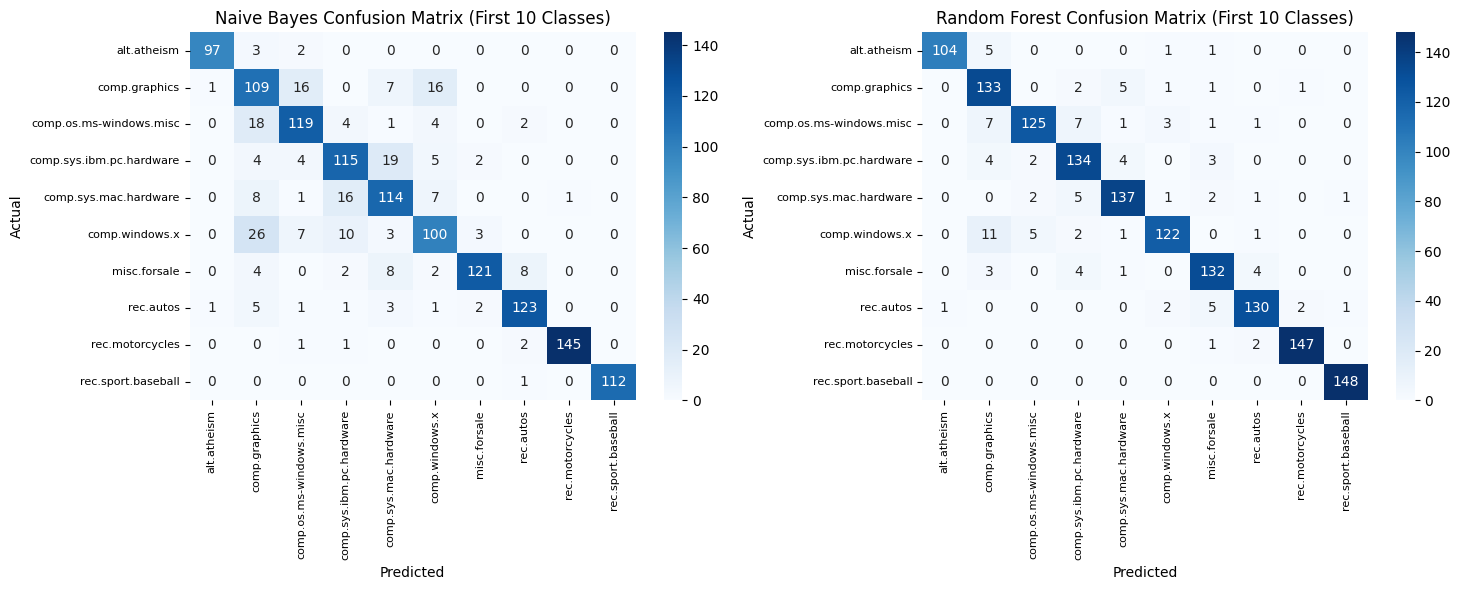

In [17]:
print("\n--- Generisanje vizualizacija ---")

# Confusion Matrix za klasifikaciju (prikaži samo prvih 10 klasa zbog čitljivosti)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Naive Bayes confusion matrix
cm_nb = confusion_matrix(y_final_test_class, nb_pred)
# Prikaži samo prvih 10x10 deo matrice
cm_nb_subset = cm_nb[:10, :10]
sns.heatmap(cm_nb_subset, annot=True, fmt='d', ax=axes[0], cmap='Blues',
           xticklabels=target_names[:10], yticklabels=target_names[:10])
axes[0].set_title('Naive Bayes Confusion Matrix (First 10 Classes)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='both', which='major', labelsize=8)

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_final_test_class, rf_pred)
cm_rf_subset = cm_rf[:10, :10]
sns.heatmap(cm_rf_subset, annot=True, fmt='d', ax=axes[1], cmap='Blues',
           xticklabels=target_names[:10], yticklabels=target_names[:10])
axes[1].set_title('Random Forest Confusion Matrix (First 10 Classes)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.savefig('classification_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Ispravljena analiza grešaka po klasama
def analyze_classification_errors(y_true, y_pred, target_names):
    """Analizira greške klasifikacije po klasama - ispravljena verzija"""
    # Dodaj debug informacije
    print(f"Debug info:")
    print(f"y_true shape: {y_true.shape}, unique values: {np.unique(y_true)}")
    print(f"y_pred shape: {y_pred.shape}, unique values: {np.unique(y_pred)}")
    print(f"target_names length: {len(target_names)}")
    print(f"target_names sample: {target_names[:5] if len(target_names) > 5 else target_names}")
    
    # Konvertuj u numpy arrays ako nisu
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    results = []
    unique_classes = np.unique(np.concatenate([y_true, y_pred]))
    
    for class_idx in unique_classes:
        # Proveri da li je class_idx validan indeks
        if class_idx >= len(target_names):
            print(f"Warning: class_idx {class_idx} >= len(target_names) {len(target_names)}")
            continue
            
        # True positives, false positives, false negatives
        tp = np.sum((y_true == class_idx) & (y_pred == class_idx))
        fp = np.sum((y_true != class_idx) & (y_pred == class_idx))
        fn = np.sum((y_true == class_idx) & (y_pred != class_idx))
        tn = np.sum((y_true != class_idx) & (y_pred != class_idx))
        
        # Support - broj stvarnih uzoraka te klase
        support = np.sum(y_true == class_idx)
        
        # Metrics
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        results.append({
            'class_idx': class_idx,
            'class': target_names[class_idx] if class_idx < len(target_names) else f'unknown_{class_idx}',
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': support,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn
        })
    
    return pd.DataFrame(results)

# Alternativna funkcija koja koristi sklearn
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

def analyze_with_sklearn(y_true, y_pred, target_names):
    """Koristi sklearn za analizu"""
    # Classification report
    report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    
    # Konvertuj u DataFrame
    results = []
    for class_name, metrics in report.items():
        if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
            results.append({
                'class': class_name,
                'precision': metrics['precision'],
                'recall': metrics['recall'],
                'f1': metrics['f1-score'],
                'support': metrics['support']
            })
    
    return pd.DataFrame(results)

print("=== SKLEARN ANALIZA ===")
try:
    nb_analysis = analyze_with_sklearn(y_final_test_class, nb_pred, target_names)
    rf_analysis = analyze_with_sklearn(y_final_test_class, rf_pred, target_names)
    
    print("\nTop 5 klasa po F1-score - Naive Bayes:")
    top_nb = nb_analysis.nlargest(5, 'f1')[['class', 'precision', 'recall', 'f1', 'support']]
    print(top_nb.to_string(index=False))
    
    print("\nTop 5 klasa po F1-score - Random Forest:")
    top_rf = rf_analysis.nlargest(5, 'f1')[['class', 'precision', 'recall', 'f1', 'support']]
    print(top_rf.to_string(index=False))
    
    print("\nNajgore 5 klasa po F1-score - Naive Bayes:")
    worst_nb = nb_analysis.nsmallest(5, 'f1')[['class', 'precision', 'recall', 'f1', 'support']]
    print(worst_nb.to_string(index=False))
    
    print("\nNajgore 5 klasa po F1-score - Random Forest:")
    worst_rf = rf_analysis.nsmallest(5, 'f1')[['class', 'precision', 'recall', 'f1', 'support']]
    print(worst_rf.to_string(index=False))
    
    print(f"\nSrednji F1-score NB: {nb_analysis['f1'].mean():.4f}")
    print(f"Srednji F1-score RF: {rf_analysis['f1'].mean():.4f}")
    print(f"Broj klasa sa F1 > 0 (NB): {(nb_analysis['f1'] > 0).sum()}/{len(nb_analysis)}")
    print(f"Broj klasa sa F1 > 0 (RF): {(rf_analysis['f1'] > 0).sum()}/{len(rf_analysis)}")

except Exception as e:
    print(f"Greška sa sklearn pristupom: {e}")
    print("\n=== CUSTOM ANALIZA SA DEBUG INFO ===")
    nb_analysis = analyze_classification_errors(y_final_test_class, nb_pred, target_names)
    rf_analysis = analyze_classification_errors(y_final_test_class, rf_pred, target_names)

# Dodatne provere
print("\n=== DODATNE PROVERE ===")
print(f"Tip y_final_test_class: {type(y_final_test_class)}")
print(f"Tip nb_pred: {type(nb_pred)}")
print(f"Tip rf_pred: {type(rf_pred)}")

# Proveri da li su predikcije validne
if hasattr(y_final_test_class, 'shape'):
    print(f"y_final_test_class shape: {y_final_test_class.shape}")
if hasattr(nb_pred, 'shape'):
    print(f"nb_pred shape: {nb_pred.shape}")
if hasattr(rf_pred, 'shape'):
    print(f"rf_pred shape: {rf_pred.shape}")

# Prva 10 vrednosti za debug
print(f"\nPrvih 10 y_true: {y_final_test_class[:10] if len(y_final_test_class) > 10 else y_final_test_class}")
print(f"Prvih 10 nb_pred: {nb_pred[:10] if len(nb_pred) > 10 else nb_pred}")
print(f"Prvih 10 rf_pred: {rf_pred[:10] if len(rf_pred) > 10 else rf_pred}")

=== SKLEARN ANALIZA ===

Top 5 klasa po F1-score - Naive Bayes:
                 class  precision   recall       f1  support
       rec.motorcycles   0.986395 0.966667 0.976431    150.0
soc.religion.christian   0.986301 0.960000 0.972973    150.0
             sci.crypt   0.972028 0.926667 0.948805    150.0
               sci.med   0.964286 0.900000 0.931034    150.0
             sci.space   0.949640 0.880000 0.913495    150.0

Top 5 klasa po F1-score - Random Forest:
                 class  precision   recall       f1  support
soc.religion.christian   0.967742 1.000000 0.983607    150.0
             sci.crypt   0.973684 0.986667 0.980132    150.0
       rec.motorcycles   0.973510 0.980000 0.976744    150.0
    rec.sport.baseball   0.942675 0.986667 0.964169    150.0
      rec.sport.hockey   0.959732 0.953333 0.956522    150.0

Najgore 5 klasa po F1-score - Naive Bayes:
             class  precision   recall       f1  support
talk.religion.misc   0.467949 0.486667 0.477124    150.0
    

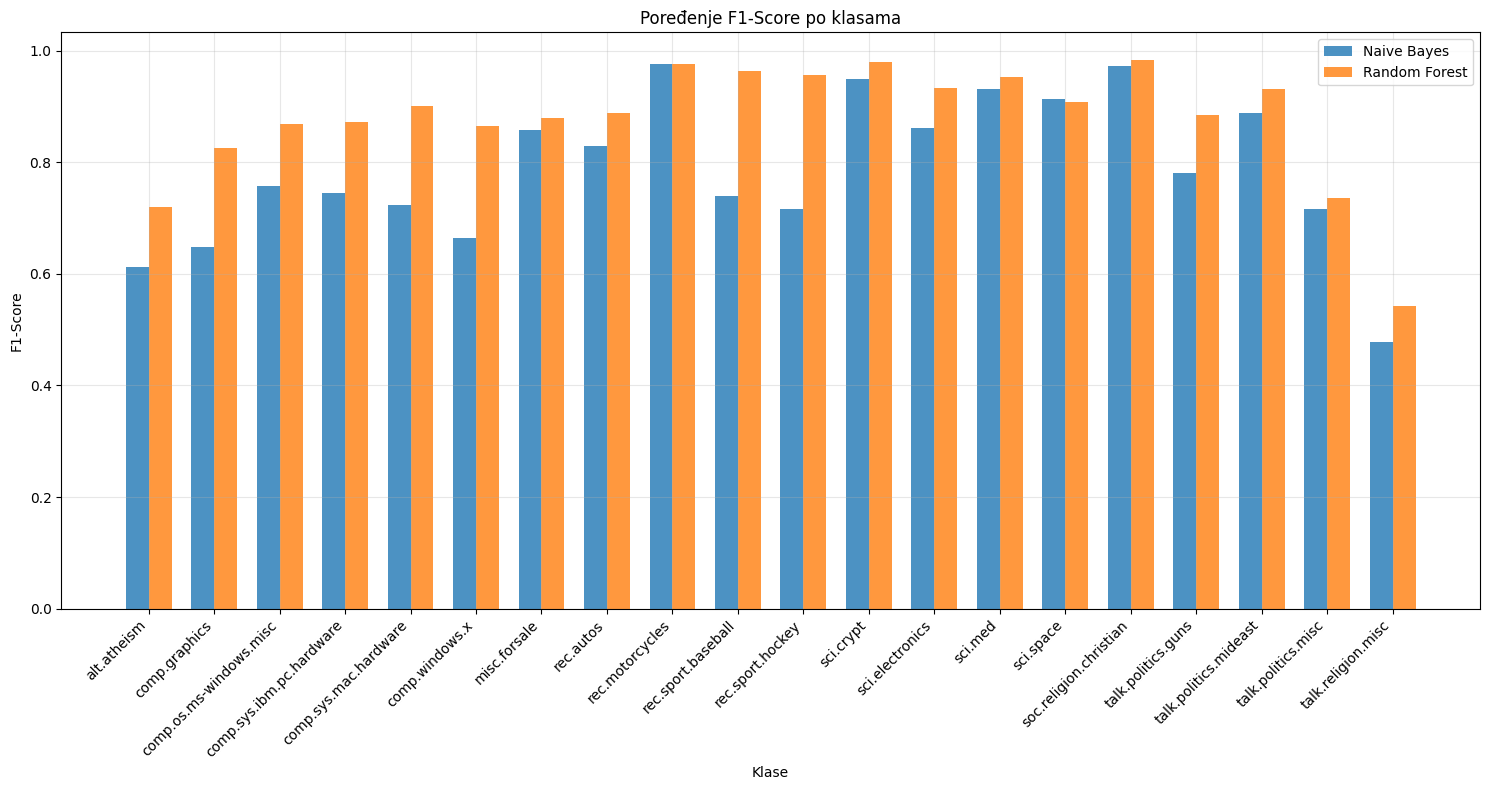

In [19]:
# Vizualizacija F1-score po klasama
plt.figure(figsize=(15, 8))

x_pos = np.arange(len(target_names))
nb_f1_scores = nb_analysis['f1'].values
rf_f1_scores = rf_analysis['f1'].values

width = 0.35
plt.bar(x_pos - width/2, nb_f1_scores, width, label='Naive Bayes', alpha=0.8)
plt.bar(x_pos + width/2, rf_f1_scores, width, label='Random Forest', alpha=0.8)

plt.xlabel('Klase')
plt.ylabel('F1-Score')
plt.title('Poređenje F1-Score po klasama')
plt.xticks(x_pos, target_names, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('f1_scores_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

## **Section 10:** Final results and saving the model

In [20]:
# Poređenje svih algoritama za klasifikaciju
results_df = pd.DataFrame({
    'Algorithm': ['Naive Bayes', 'Random Forest'],
    'Accuracy': [nb_acc, rf_acc],
    'F1-score (macro)': [nb_f1, rf_f1],
    'Dimensionality Reduction': [
        'LDA' if use_lda_nb else 'None',
        'LDA' if use_lda_rf else 'None'
    ],
    'Best CV Score': [
        grid_search_nb_lda.best_score_ if use_lda_nb else grid_search_nb.best_score_,
        grid_search_rf_lda.best_score_ if use_lda_rf else grid_search_rf.best_score_
    ]
})

print("\n" + "="*50)
print("FINALNI REZULTATI - TEXT CLASSIFICATION")
print("="*50)
print(results_df.to_string(index=False))

# Najbolji algoritam
best_algorithm = results_df.loc[results_df['F1-score (macro)'].idxmax(), 'Algorithm']
best_f1 = results_df['F1-score (macro)'].max()
print(f"\nNajbolji algoritam: {best_algorithm} sa F1-score: {best_f1:.4f}")


FINALNI REZULTATI - TEXT CLASSIFICATION
    Algorithm  Accuracy  F1-score (macro) Dimensionality Reduction  Best CV Score
  Naive Bayes  0.784667          0.788031                      LDA       0.979671
Random Forest  0.878667          0.878484                      LDA       0.975807

Najbolji algoritam: Random Forest sa F1-score: 0.8785


In [21]:
# Analiza uticaja LDA na performanse
print(f"\n--- Analiza uticaja LDA ---")
print(f"Naive Bayes bez LDA: CV={grid_search_nb.best_score_:.4f}")
print(f"Naive Bayes sa LDA: CV={grid_search_nb_lda.best_score_:.4f}")
print(f"Poboljšanje NB: {(grid_search_nb_lda.best_score_ - grid_search_nb.best_score_)*100:.2f}%")

print(f"\nRandom Forest bez LDA: CV={grid_search_rf.best_score_:.4f}")
print(f"Random Forest sa LDA: CV={grid_search_rf_lda.best_score_:.4f}")
print(f"Poboljšanje RF: {(grid_search_rf_lda.best_score_ - grid_search_rf.best_score_)*100:.2f}%")

print(f"\nRedukcija dimenzionalnosti:")
print(f"Originalno: {X_train_tfidf_class.shape[1]} features")
print(f"Sa LDA: {X_train_lda.shape[1]} features")
print(f"Redukcija: {((X_train_tfidf_class.shape[1] - X_train_lda.shape[1]) / X_train_tfidf_class.shape[1] * 100):.1f}%")


--- Analiza uticaja LDA ---
Naive Bayes bez LDA: CV=0.8858
Naive Bayes sa LDA: CV=0.9797
Poboljšanje NB: 9.39%

Random Forest bez LDA: CV=0.9512
Random Forest sa LDA: CV=0.9758
Poboljšanje RF: 2.46%

Redukcija dimenzionalnosti:
Originalno: 10000 features
Sa LDA: 19 features
Redukcija: 99.8%


In [22]:
print("\n--- Čuvanje modela ---")

# Čuvanje najboljih modela
if use_lda_nb:
    joblib.dump(grid_search_nb_lda.best_estimator_, 'final_nb_classification_model.pkl')
    print("Naive Bayes model (sa LDA) sačuvan")
else:
    joblib.dump(best_nb, 'final_nb_classification_model.pkl')
    print("Naive Bayes model (bez LDA) sačuvan")

if use_lda_rf:
    joblib.dump(grid_search_rf_lda.best_estimator_, 'final_rf_classification_model.pkl')
    print("Random Forest model (sa LDA) sačuvan")
else:
    joblib.dump(best_rf, 'final_rf_classification_model.pkl')
    print("Random Forest model (bez LDA) sačuvan")

# Čuvanje transformera
joblib.dump(tfidf_class, 'tfidf_classification_vectorizer.pkl')
joblib.dump(lda, 'lda_transformer.pkl')

print("\nSvi classification modeli su sačuvani:")
print("- final_nb_classification_model.pkl")
print("- final_rf_classification_model.pkl")
print("- tfidf_classification_vectorizer.pkl")
print("- lda_transformer.pkl")

# Čuvanje target_names za buduće korišćenje
joblib.dump(target_names, 'target_names.pkl')
print("- target_names.pkl")


--- Čuvanje modela ---
Naive Bayes model (sa LDA) sačuvan
Random Forest model (sa LDA) sačuvan

Svi classification modeli su sačuvani:
- final_nb_classification_model.pkl
- final_rf_classification_model.pkl
- tfidf_classification_vectorizer.pkl
- lda_transformer.pkl
- target_names.pkl


## **Section 11:** Additional analysis


--- LDA Komponente Analiza ---


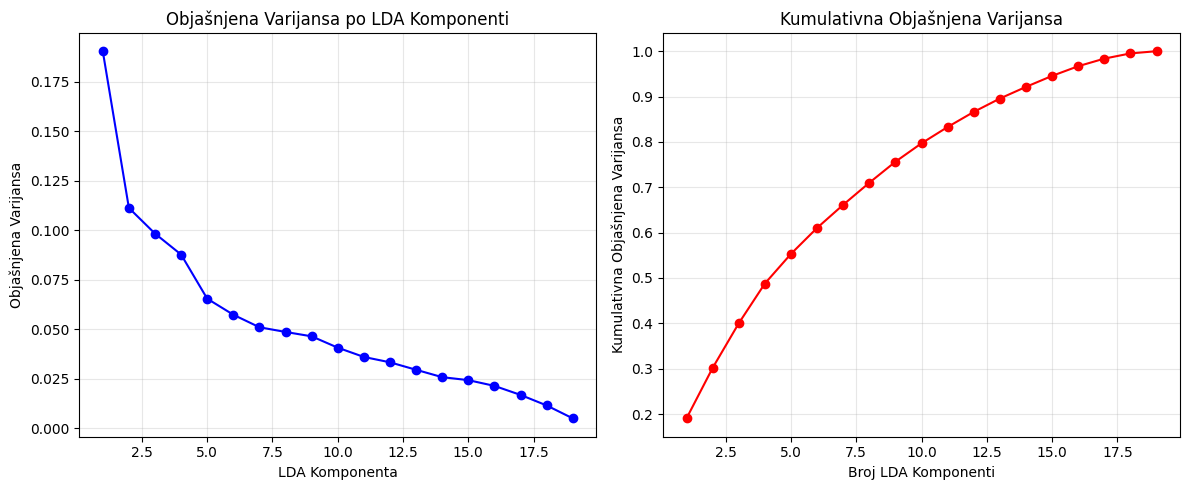

Prvih 10 komponenti objašnjava 0.797 varijanse
Ukupno objašnjena varijansa: 1.000


In [23]:
print(f"\n--- LDA Komponente Analiza ---")
if hasattr(lda, 'explained_variance_ratio_'):
    # Vizualizacija objašnjene varijanse po komponentama
    plt.figure(figsize=(12, 5))
    
    # Subplot 1: Objašnjena varijansa po komponentama
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(lda.explained_variance_ratio_)+1), lda.explained_variance_ratio_, 'bo-')
    plt.xlabel('LDA Komponenta')
    plt.ylabel('Objašnjena Varijansa')
    plt.title('Objašnjena Varijansa po LDA Komponenti')
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Kumulativna objašnjena varijansa
    plt.subplot(1, 2, 2)
    cumsum_var = np.cumsum(lda.explained_variance_ratio_)
    plt.plot(range(1, len(cumsum_var)+1), cumsum_var, 'ro-')
    plt.xlabel('Broj LDA Komponenti')
    plt.ylabel('Kumulativna Objašnjena Varijansa')
    plt.title('Kumulativna Objašnjena Varijansa')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('lda_variance_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Prvih 10 komponenti objašnjava {cumsum_var[9]:.3f} varijanse")
    print(f"Ukupno objašnjena varijansa: {cumsum_var[-1]:.3f}")